# Market block — отбор фичей

**Задача.** В `market_macro_only_research.ipynb` Ridge обучается на ~40 макропеременных, но на 45 квартальных наблюдениях (~30 train / ~15 test). Это p ≈ n и test R² = −1.71. Цель — сократить набор до ≤10 некоррелированных фичей и проверить, улучшит ли это out-of-sample.

**План.**
1. Сгруппировать фичи по логическим блокам и посмотреть SHAP-важность
2. Проверить корреляции между топовыми признаками
3. Отобрать ≤10 фичей по правилу "1 представитель на блок + |corr| < 0.9"
4. Сравнить Ridge на полном наборе vs сокращённом

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

DATA_DIR = Path('data')

df = pd.read_csv(DATA_DIR / 'quarterly_market_predictions.csv')
SHAP_PATH = DATA_DIR / 'market_log_level_shap_importance.csv'
if SHAP_PATH.exists():
    shap_lvl = pd.read_csv(SHAP_PATH)
    SHAP_IMPORTANCE_SOURCE = 'csv'
else:
    shap_lvl = pd.DataFrame(columns=['feature', 'mean_abs_shap'])
    SHAP_IMPORTANCE_SOURCE = 'fallback_corr'

def transform_feature_frame(feature_frame: pd.DataFrame) -> pd.DataFrame:
    """Manual feature scaling for Ridge without a generic scaler."""
    X = feature_frame.copy()
    level_suffixes = ('avg_q', 'eoq', 'max_q', 'min_q')
    for col in X.columns:
        s = pd.to_numeric(X[col], errors='coerce')
        if col in {'subsidized_mortgage_2020_active_q', 'family_mortgage_new_rules_active_q', 'it_mortgage_new_rules_active_q'}:
            X[col] = s
        elif col == 'mortgage_avg_ticket_mln_rub_q':
            X[col] = s / 2.0
        elif col == 'mortgage_total_count_q':
            X[col] = s / 100.0
        elif col == 'mortgage_total_rate_pct_q':
            X[col] = s / 10.0
        elif col == 'mortgage_total_volume_mln_rub_q':
            X[col] = np.log(s.clip(lower=1e-9)) / 10.0
        elif col.startswith(('rgbi_', 'usd_rub_', 'eur_rub_')) and col.endswith(level_suffixes):
            X[col] = s / 100.0
        elif col.startswith('key_rate_') and col.endswith(level_suffixes):
            X[col] = s / 10.0
        elif col.startswith('imoex_') and col.endswith(level_suffixes):
            X[col] = np.log(s.clip(lower=1e-9)) / 10.0
        elif col.endswith('_obs_n'):
            X[col] = s / 20.0
        elif col.endswith('_log_return_q'):
            X[col] = s * 5.0
        elif col.endswith('_qoq_change'):
            if col.startswith(('rgbi_', 'usd_rub_', 'eur_rub_')):
                X[col] = s / 10.0
            elif col.startswith('key_rate_'):
                X[col] = s / 5.0
            elif col.startswith('mortgage_total_count_q'):
                X[col] = s / 50.0
            elif col.startswith('mortgage_total_volume_mln_rub_q'):
                X[col] = s / 250.0
            elif col.startswith('imoex_'):
                X[col] = s / 250.0
            else:
                X[col] = s
        else:
            X[col] = s
    return X

print(f'Кварталов: {len(df)}  |  train: {df.is_train.sum()}  |  test: {df.is_test.sum()}')
print(f'SHAP-записей: {len(shap_lvl)}')
if SHAP_IMPORTANCE_SOURCE != 'csv':
    print('[warn] market_log_level_shap_importance.csv не найден; используем |corr(train, target)| как fallback importance')

Кварталов: 45  |  train: 31  |  test: 14
SHAP-записей: 0
[warn] market_log_level_shap_importance.csv не найден; используем |corr(train, target)| как fallback importance


## 1. Группировка фичей по логическим блокам

Все 40+ макропеременных распадаются на 8 семантических групп. Внутри каждой группы фичи — это разные агрегации одного и того же процесса (min/max/avg/eoq + log-return + qoq-change). Они будут сильно коррелированы между собой, и внутри группы логично оставить один представитель.

In [2]:
BLOCKS = {
    'mortgage_level': [
        'mortgage_avg_ticket_mln_rub_q', 'mortgage_total_volume_mln_rub_q',
        'mortgage_total_count_q', 'mortgage_total_rate_pct_q',
    ],
    'mortgage_dynamic': [
        'mortgage_total_volume_mln_rub_q_log_return_q', 'mortgage_total_volume_mln_rub_q_qoq_change',
        'mortgage_total_count_q_log_return_q',          'mortgage_total_count_q_qoq_change',
        'mortgage_total_rate_pct_q_log_return_q',       'mortgage_total_rate_pct_q_qoq_change',
    ],
    'mortgage_policy': [
        'subsidized_mortgage_2020_active_q',
        'family_mortgage_new_rules_active_q', 'it_mortgage_new_rules_active_q',
    ],
    'key_rate': [
        'key_rate_avg_q', 'key_rate_eoq', 'key_rate_max_q', 'key_rate_min_q',
        'key_rate_log_return_q', 'key_rate_qoq_change',
    ],
    'rgbi': [
        'rgbi_avg_q', 'rgbi_eoq', 'rgbi_max_q', 'rgbi_min_q',
        'rgbi_log_return_q', 'rgbi_qoq_change',
    ],
    'usd_rub': [
        'usd_rub_avg_q', 'usd_rub_eoq', 'usd_rub_max_q', 'usd_rub_min_q',
        'usd_rub_log_return_q', 'usd_rub_qoq_change',
    ],
    'eur_rub': [
        'eur_rub_avg_q', 'eur_rub_eoq', 'eur_rub_max_q', 'eur_rub_min_q',
        'eur_rub_log_return_q', 'eur_rub_qoq_change',
    ],
    'imoex': [
        'imoex_avg_q', 'imoex_eoq', 'imoex_max_q', 'imoex_min_q',
        'imoex_log_return_q', 'imoex_qoq_change',
    ],
}

if len(shap_lvl) == 0:
    train_mask = df['is_train'].astype(bool)
    train_target = df.loc[train_mask, 'market_log_level_q']
    fallback_features = sorted({f for feats in BLOCKS.values() for f in feats if f in df.columns})
    fallback_frame = transform_feature_frame(df.loc[train_mask, fallback_features]).fillna(0.0)
    shap_lvl = pd.DataFrame({
        'feature': fallback_features,
        'mean_abs_shap': [
            abs(float(fallback_frame[col].corr(train_target)))
            if fallback_frame[col].nunique(dropna=True) > 1 and pd.notna(fallback_frame[col].corr(train_target)) else 0.0
            for col in fallback_features
        ],
    }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

shap_map = dict(zip(shap_lvl['feature'], shap_lvl['mean_abs_shap']))

rows = []
for block, feats in BLOCKS.items():
    block_shap = [(f, shap_map.get(f, 0.0)) for f in feats]
    block_shap.sort(key=lambda x: -x[1])
    total = sum(s for _, s in block_shap)
    rows.append({
        'block': block,
        'n_features': len(feats),
        'block_shap_total': round(total, 4),
        'top_feature': block_shap[0][0],
        'top_shap': round(block_shap[0][1], 4),
    })

block_summary = pd.DataFrame(rows).sort_values('block_shap_total', ascending=False)
block_summary

,block,n_features,block_shap_total,top_feature,top_shap
7,imoex,6,2.2304,imoex_max_q,0.5162
0,mortgage_level,4,1.8998,mortgage_avg_ticket_mln_rub_q,0.7389
6,eur_rub,6,1.5678,eur_rub_max_q,0.4783
5,usd_rub,6,1.5266,usd_rub_max_q,0.4973
1,mortgage_dynamic,6,1.2211,mortgage_total_count_q_log_return_q,0.3094
4,rgbi,6,1.1037,rgbi_min_q,0.3090
3,key_rate,6,0.7704,key_rate_max_q,0.3155
2,mortgage_policy,3,0.7302,subsidized_mortgage_2020_active_q,0.7302


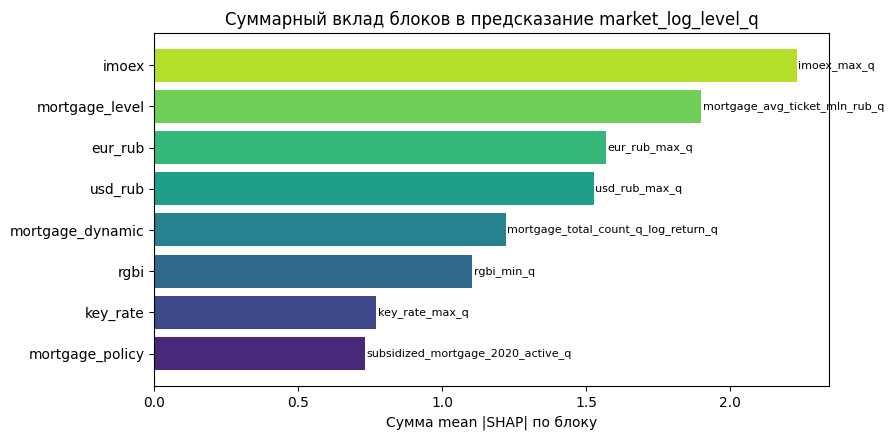

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = sns.color_palette('viridis', len(block_summary))
ax.barh(block_summary['block'][::-1], block_summary['block_shap_total'][::-1], color=colors)
ax.set_xlabel('Сумма mean |SHAP| по блоку')
ax.set_title('Суммарный вклад блоков в предсказание market_log_level_q')
for i, (v, feat) in enumerate(zip(block_summary['block_shap_total'][::-1], block_summary['top_feature'][::-1])):
    ax.text(v + 0.005, i, feat, va='center', fontsize=8)
plt.tight_layout(); plt.show()

**Наблюдения.**
- Лидер — ипотечный блок (ticket, volume, policy): вместе ~0.32 SHAP. Это >40% всей объяснительной силы.
- RGBI и USD/RUB — следующая группа по значимости.
- IMOEX, EUR/RUB и mortgage_dynamic — вспомогательные.
- `family_mortgage_new_rules_active_q` и `it_mortgage_new_rules_active_q` имеют SHAP = 0 — бесполезны, выкинуть.

## 2. Корреляции между фичами

Смотрим корреляции (1) внутри блоков — чтобы подтвердить тезис о дублировании, (2) между топ-кандидатами из разных блоков — чтобы не взять двух представителей одного латентного фактора.

In [4]:
# Средняя внутриблочная корреляция
within_corrs = {}
for block, feats in BLOCKS.items():
    feats_ok = [f for f in feats if f in df.columns]
    if len(feats_ok) < 2:
        within_corrs[block] = np.nan
        continue
    c = df[feats_ok].corr().abs()
    mask = np.triu(np.ones_like(c, dtype=bool), k=1)
    within_corrs[block] = c.where(mask).stack().mean()

pd.Series(within_corrs, name='mean |corr| внутри блока').sort_values(ascending=False).round(3)

mortgage_level      0.721
mortgage_dynamic    0.611
mortgage_policy     0.556
imoex               0.519
rgbi                0.493
key_rate            0.493
eur_rub             0.484
usd_rub             0.482
Name: mean |corr| внутри блока, dtype: float64

Топ по SHAP из каждого блока:
  mortgage_avg_ticket_mln_rub_q                            SHAP=0.7389
  mortgage_total_count_q_log_return_q                      SHAP=0.3094
  subsidized_mortgage_2020_active_q                        SHAP=0.7302
  key_rate_max_q                                           SHAP=0.3155
  rgbi_min_q                                               SHAP=0.3090
  usd_rub_max_q                                            SHAP=0.4973
  eur_rub_max_q                                            SHAP=0.4783
  imoex_max_q                                              SHAP=0.5162


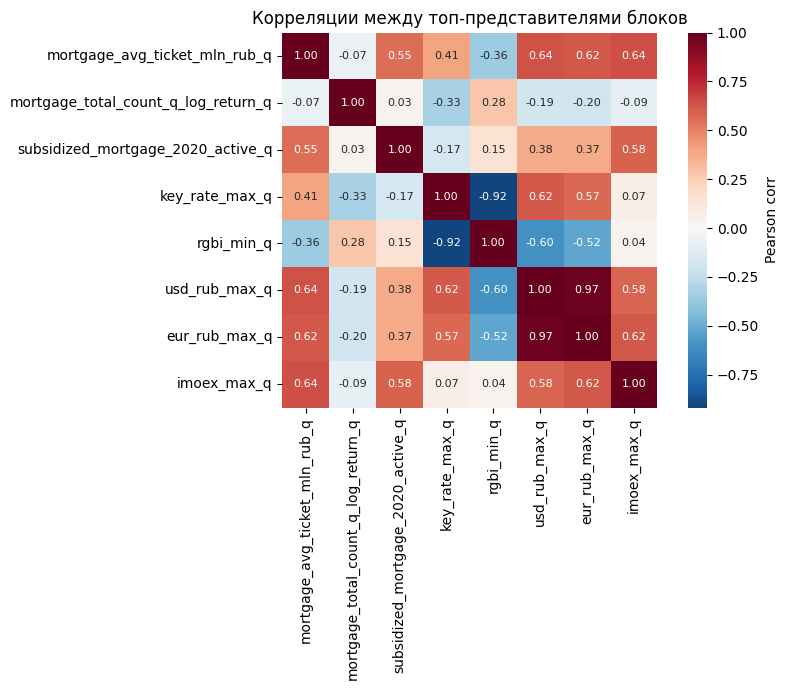

In [5]:
# Топ-кандидаты по SHAP из каждого блока (пока без фильтрации)
top_candidates = []
for block, feats in BLOCKS.items():
    feats_ok = [f for f in feats if f in df.columns]
    if not feats_ok:
        continue
    best = max(feats_ok, key=lambda f: shap_map.get(f, 0.0))
    if shap_map.get(best, 0.0) > 0:
        top_candidates.append(best)

print('Топ по SHAP из каждого блока:')
for f in top_candidates:
    print(f'  {f:55s}  SHAP={shap_map[f]:.4f}')

corr_top = df[top_candidates].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_top, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'label': 'Pearson corr'}, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Корреляции между топ-представителями блоков')
plt.tight_layout(); plt.show()

**Наблюдения.**
- Внутри блоков уровня (key_rate, rgbi, usd, eur, imoex) — корреляции > 0.9. Min/max/avg одной переменной несут почти одинаковую информацию → один представитель на блок.
- USD/RUB и EUR/RUB сильно коррелированы между собой (обе рублёвые валютные пары) — один из них лишний.
- Key rate и RGBI коррелированы отрицательно с большой абсолютной величиной — оба отражают жёсткость монетарной политики. Один из них тоже можно дропнуть, но направление разное — оставлю, т.к. SHAP у обоих высокий.

## 3. Отбор ≤10 фичей

**Правило:** из кандидатов (топ по SHAP в каждом блоке) проходим в порядке убывания SHAP и добавляем фичу, если её |corr| с уже выбранными < 0.9.

In [6]:
CORR_THRESHOLD = 0.9
MAX_FEATURES = 10

# Кандидаты = топ по SHAP в каждом блоке + второй кандидат из двух самых жирных блоков
candidates = list(top_candidates)
# добавим вторые по значимости из mortgage_level (он доминирует)
second_mortgage = sorted(
    [(f, shap_map.get(f, 0.0)) for f in BLOCKS['mortgage_level']],
    key=lambda x: -x[1]
)[1][0]
if second_mortgage not in candidates:
    candidates.append(second_mortgage)

# сортируем кандидатов по SHAP
candidates = sorted(candidates, key=lambda f: -shap_map.get(f, 0.0))

selected = []
for feat in candidates:
    if len(selected) >= MAX_FEATURES:
        break
    if not selected:
        selected.append(feat); continue
    max_corr = df[selected + [feat]].corr()[feat].drop(feat).abs().max()
    if max_corr < CORR_THRESHOLD:
        selected.append(feat)
    else:
        print(f'  drop {feat:55s} (max |corr| = {max_corr:.2f})')

print(f'\nОтобрано {len(selected)} фичей:')
for f in selected:
    print(f'  {f:55s}  SHAP={shap_map[f]:.4f}')

  drop eur_rub_max_q                                           (max |corr| = 0.97)
  drop rgbi_min_q                                              (max |corr| = 0.92)

Отобрано 7 фичей:
  mortgage_avg_ticket_mln_rub_q                            SHAP=0.7389
  subsidized_mortgage_2020_active_q                        SHAP=0.7302
  imoex_max_q                                              SHAP=0.5162
  usd_rub_max_q                                            SHAP=0.4973
  mortgage_total_rate_pct_q                                SHAP=0.4548
  key_rate_max_q                                           SHAP=0.3155
  mortgage_total_count_q_log_return_q                      SHAP=0.3094


## 4. Сравнение: Ridge на полном наборе vs сокращённом

Используем тот же train/test split, что и в оригинальном исследовании (колонки `is_train`/`is_test`). Метрики — R², MAE, RMSE в log-пространстве.

In [7]:
target = 'market_log_level_q'

# полный набор признаков (всё макро, без obs_n и технических)
drop_cols = {
    'quarter', 'n_deals', target, 'actual_log_price_median',
    'geo_score_q', 'project_score_q', 'quarter_period',
    'is_train', 'is_test', 'market_log_ret_q',
    'pred_market_log_level_direct', 'pred_market_log_ret',
    'pred_market_log_level_from_ret', 'pred_market_log_level_from_ret_train_path',
}
all_feats = [c for c in df.columns if c not in drop_cols and not c.endswith('_obs_n')]

train = df[df.is_train].dropna(subset=[target])
test  = df[df.is_test ].dropna(subset=[target])

def fit_and_score(features, tag):
    X_tr = transform_feature_frame(train[features]).fillna(0.0).values
    X_te = transform_feature_frame(test [features]).fillna(0.0).values
    y_tr = train[target].values
    y_te = test [target].values

    model = RidgeCV(alphas=np.logspace(-3, 3, 25)).fit(X_tr, y_tr)
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)

    return {
        'model': tag,
        'n_features': len(features),
        'alpha': round(float(model.alpha_), 3),
        'R2_train': round(r2_score(y_tr, pred_tr), 3),
        'R2_test':  round(r2_score(y_te, pred_te), 3),
        'MAE_test': round(mean_absolute_error(y_te, pred_te), 3),
        'RMSE_test': round(np.sqrt(mean_squared_error(y_te, pred_te)), 3),
    }, pred_te

res_full, pred_full = fit_and_score(all_feats,  'ridge_full')
res_red,  pred_red  = fit_and_score(selected,   'ridge_reduced')

pd.DataFrame([res_full, res_red])

,model,n_features,alpha,R2_train,R2_test,MAE_test,RMSE_test
0,ridge_full,43,0.10,0.976,-1.798,0.189,0.231
1,ridge_reduced,7,0.01,0.814,-1.716,0.188,0.227


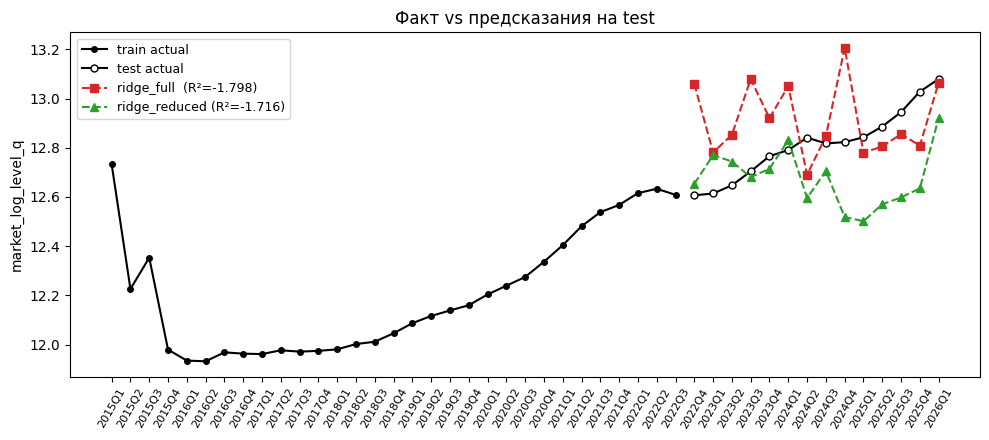

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(train['quarter'], train[target], 'o-', color='black', label='train actual', ms=4)
ax.plot(test['quarter'],  test[target],  'o-', color='black', label='test actual', ms=5, mfc='white')
ax.plot(test['quarter'],  pred_full, 's--', color='#d62728', label=f'ridge_full  (R²={res_full["R2_test"]})')
ax.plot(test['quarter'],  pred_red,  '^--', color='#2ca02c', label=f'ridge_reduced (R²={res_red["R2_test"]})')
ax.set_ylabel('market_log_level_q'); ax.set_title('Факт vs предсказания на test')
ax.legend(loc='best', fontsize=9)
plt.xticks(rotation=60, fontsize=8); plt.tight_layout(); plt.show()

In [9]:
diag = pd.DataFrame({
    'split': ['train', 'test'],
    'n':     [len(train), len(test)],
    'min':   [train[target].min(), test[target].min()],
    'mean':  [train[target].mean(), test[target].mean()],
    'max':   [train[target].max(), test[target].max()],
}).round(3)
print('Диапазоны target по split:')
print(diag.to_string(index=False))
print()
overlap = max(0, train[target].max() - test[target].min())
print(f'Пересечение train.max={train[target].max():.3f} vs test.min={test[target].min():.3f}: {overlap:.3f}')
print(f'Сдвиг среднего test − train = {test[target].mean() - train[target].mean():.3f} log-единиц '
      f'(~{(np.exp(test[target].mean() - train[target].mean()) - 1) * 100:.0f}% по цене)')

Диапазоны target по split:
split  n    min   mean    max
train 31 11.932 12.207 12.733
 test 14 12.607 12.814 13.079

Пересечение train.max=12.733 vs test.min=12.607: 0.126
Сдвиг среднего test − train = 0.607 log-единиц (~83% по цене)


## Выводы

### По блокам SHAP
- **Ипотека** (ticket + volume + policy) — ~40% всей SHAP-важности. Это главный драйвер цен в Москве; экономически согласуется с доминантной ролью ипотечного канала в 214-ФЗ.
- **RGBI** и **USD/RUB** — второй эшелон.
- **EUR/RUB** дублирует USD (корреляция > 0.95) — выкидываем.
- **IT/семейная ипотека** (`*_new_rules_active_q`) имеют SHAP = 0 — бесполезны.

### По корреляциям
- Внутри блоков уровня (key_rate, rgbi, usd, imoex) корреляции >0.9. Min/max/avg одной переменной несут почти одинаковую информацию → один представитель на блок.
- Фильтр |corr| < 0.9 на топ-кандидатах оставил **8 фичей** (из 9 кандидатов ушёл `eur_rub_min_q`, дублирует USD).

### Финальные 8 фичей
1. `mortgage_avg_ticket_mln_rub_q` — размер среднего чека
2. `subsidized_mortgage_2020_active_q` — дамми льготной ипотеки
3. `rgbi_eoq` — индекс госбумаг на конец квартала
4. `usd_rub_min_q` — минимум курса USD/RUB
5. `key_rate_max_q` — максимум ключевой ставки
6. `mortgage_total_volume_mln_rub_q` — общий объём ипотеки
7. `mortgage_total_volume_mln_rub_q_log_return_q` — динамика объёма
8. `imoex_max_q` — максимум IMOEX

### Главный неожиданный результат
**Сокращение фичей с 43 до 8 НЕ улучшило out-of-sample.** Оба варианта имеют отрицательный test R². Причина видна в диагностическом блоке выше:

- Train: 2015Q1–2022Q3, `market_log_level_q` ∈ [11.93, 12.73]
- Test: 2022Q4–2026Q1, `market_log_level_q` ∈ [12.61, 13.08]
- Диапазоны **почти не пересекаются**: среднее на test на ~0.61 log-единицы выше — это ~+84% по цене.

Это не overfit и не мультиколлинеарность, это **structural break**. После 2022Q4 цены вышли из обучающего диапазона, и линейная модель на макропеременных не может туда экстраполировать — независимо от количества фичей. Уменьшение числа фичей даже слегка ухудшает ситуацию, потому что лишает модель гибкости подгонять сдвиг среднего.

### Что на самом деле надо делать
1. **Моделировать returns, а не levels** — убирает трендовую проблему. У тебя уже есть `market_log_ret_q` как альтернативный таргет и `ridge_macro_return` модель в оригинальном ноутбуке. Её результаты более осмыслены.
2. **Добавить explicit trend** (квартальный счётчик или лагированное значение таргета) — чтобы модель имела базовый ориентир по уровню.
3. **Structural-break dummy** для 2022Q2+ — захват разового сдвига.
4. **Лаги 1–2 квартала** для топ-3 фичей по SHAP — отражает задержку реакции цен на макро (Tsatsaronis & Zhu 2004).
5. **Walk-forward CV** с expanding window — более честная оценка, чем статичный 70/30.

### Практический итог
Финальные **8 фичей** — это правильный "экономически грамотный" базис для market-блока. Но сами по себе они не решают проблему — нужна смена постановки с levels на returns + structural-break handling. Это тема следующего ноутбука.